Оригинальный размер: 190x149
Увеличенный размер: 760x596


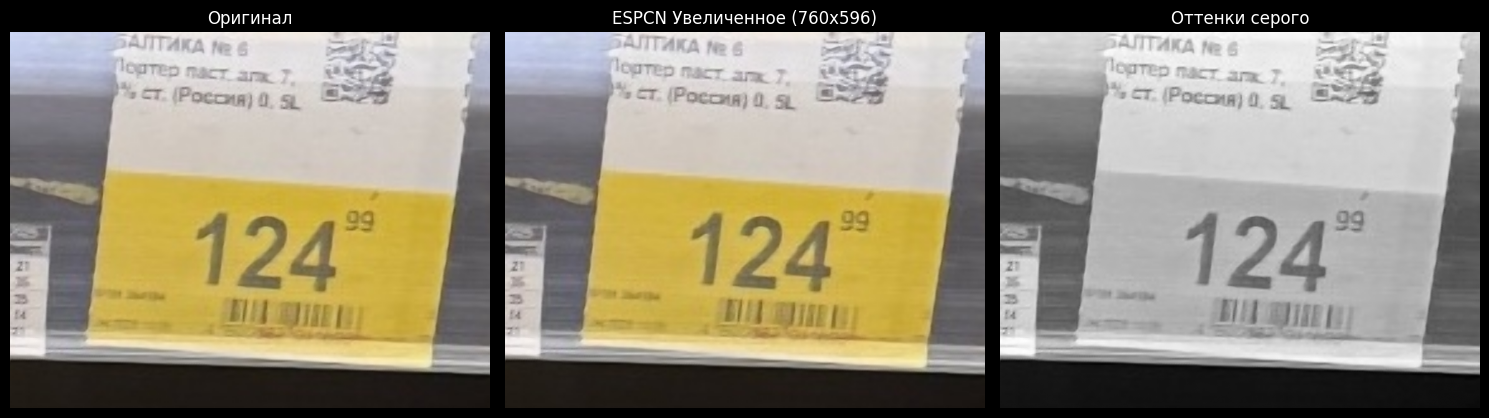


Результаты сохранены в папку: ocr_preprocessed


In [13]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# Создаём объект для супер-разрешения
sr = cv2.dnn_superres.DnnSuperResImpl_create()

# Путь к файлу модели
model_path = "../weight/ESPCN_x4.pb"
scale_factor = 4

# Загружаем модель
sr.readModel(model_path)
sr.setModel("espcn", scale_factor)

# Загружаем изображение
image_path = "../outputs/extracted_price_tags_25_12_20/IMG_0508_tag_011.jpg"

# ========== ПРЕДОБРАБОТКА ДЛЯ OCR ==========

def preprocess_for_ocr(image_path):
    """
    Предобработка изображения для улучшения распознавания OCR
    """
    img = cv2.imread(image_path)

    if img is None:
        print(f"Ошибка: не удалось загрузить изображение {image_path}")
        exit()

    print(f"Оригинальный размер: {img.shape[1]}x{img.shape[0]}")

    # Увеличиваем разрешение с помощью ESPCN
    result = sr.upsample(img)
    print(f"Увеличенный размер: {result.shape[1]}x{result.shape[0]}")

    # Конвертируем в оттенки серого
    gray = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)


    return img, result, gray

# Применяем предобработку
img, result, gray = preprocess_for_ocr(image_path)


# ========== ВИЗУАЛИЗАЦИЯ ==========

plt.figure(figsize=(15, 12))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f'Оригинал')
plt.axis('off')

# Оригинал (увеличенный ESPCN)
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f'ESPCN Увеличенное ({result.shape[1]}x{result.shape[0]})')
plt.axis('off')

# Оттенки серого
plt.subplot(1, 3, 3)
plt.imshow(gray, cmap='gray')
plt.title('Оттенки серого')
plt.axis('off')

plt.tight_layout()
plt.show()

# Сохраняем все этапы обработки
output_dir = "ocr_preprocessed"
os.makedirs(output_dir, exist_ok=True)

print(f"\nРезультаты сохранены в папку: {output_dir}")